This notebook is to display and compare the results I personally conducted and the results found by the paper. This is to make sure what we're getting is correct!

## Import libraries

In [1]:
import matplotlib.pyplot as plt

In [2]:
# Quick code to load json files and get stats
import json
import re
def getStats( filename ):
    with open( filename, 'r') as file:
        data = json.load(file)

    X = []
    response50 = []
    response95 = []
    hitrate = []
    throughput = []
    for key in data:
        X.append( key )

        key_data = data[key]
        raw = key_data["raw"]

        # print( raw )
        match = re.search(r'/.*50\.00\% in (\d+\.\d+) secs.*95\.00\% in (\d+\.\d+) secs', raw, flags = re.DOTALL)
        response50.append( float( match.group(1) ) * 1000 )
        response95.append( float( match.group(2) ) * 1000 )

        if( "hit_rate" in key_data ):
            hitrate.append( key_data["hit_rate"] )
        throughput.append( key_data["throughput"] )

    out = {"50": response50, "95":response95,"hit_rate":hitrate,"throughput":throughput}
    return X, out

In [3]:
def plotStats( X, plots, xLabel, yLabel, title, log_scale = False, i = 0, ylim = -1 ):

    for label, plot in plots:
        if( i == 0 ):
            plt.plot(X, plot, label=label )
        else:
            plt.plot(X[:i], plot[:i], label=label)

    if( log_scale ):
        plt.yscale( "log" )
        plt.ylabel( yLabel + " (Log Scaled)" )
    else:
        if( ylim > 0 ):
            plt.ylim(0, ylim)
        plt.ylabel(yLabel)
    plt.grid()
    plt.xlabel(xLabel)
    plt.title(title)
    plt.legend()
    plt.show()
    

## Cache Size Experiment

The reported experiment is this:

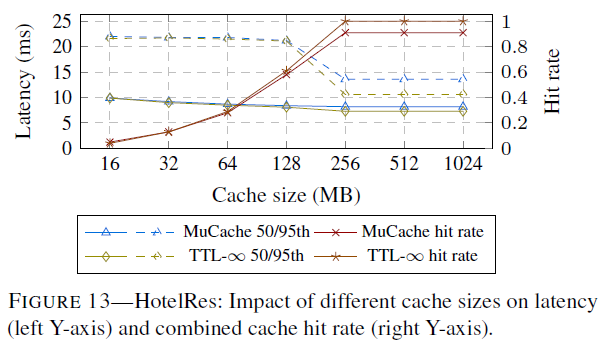

Our results are as follows:


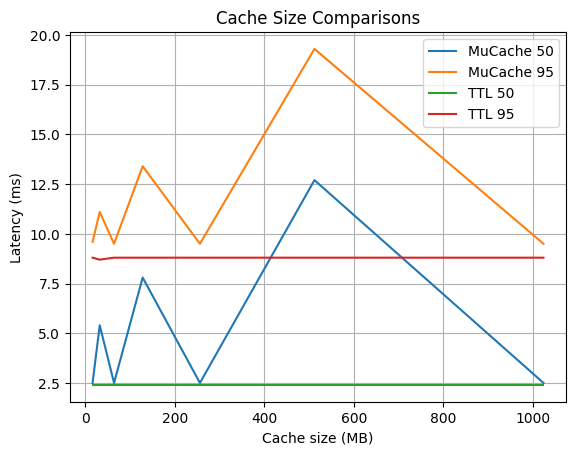

In [4]:
x = [16,32,64,128,256,512,1024]

# m510
_, mucache_out = getStats("hotel-md-5000app-12proxy-4zmq.json")
_, ttl_out = getStats("hotel-md-upper-5000app-12proxy-4zmq.json")

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]]]
plotStats( x, plots, "Cache size (MB)", "Latency (ms)", "Cache Size Comparisons" )

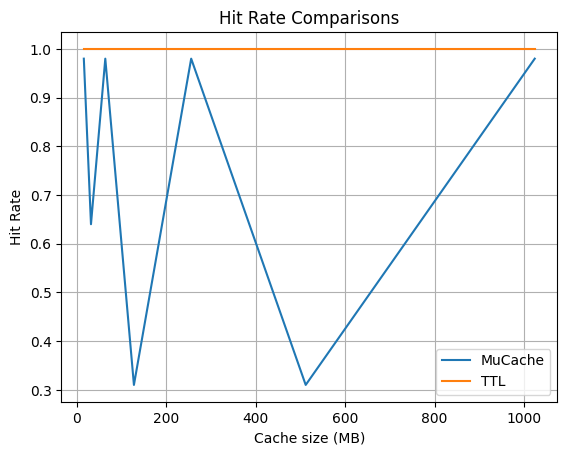

In [5]:
# Also plot the hitrate
#print( mucache_out["hit_rate"] )
plots = [["MuCache", [ float( hr["frontend"] ) for hr in mucache_out["hit_rate"]]],
         ["TTL", [ float( hr["frontend"] ) for hr in ttl_out["hit_rate"]]]
        ]
plotStats( x, plots, "Cache size (MB)", "Hit Rate", "Hit Rate Comparisons" )

### Analysis
Looking at the graphs, it seems like there might be something wrong with calculating the hitrate. This may require additional work to investigate.

## Microbenchmark

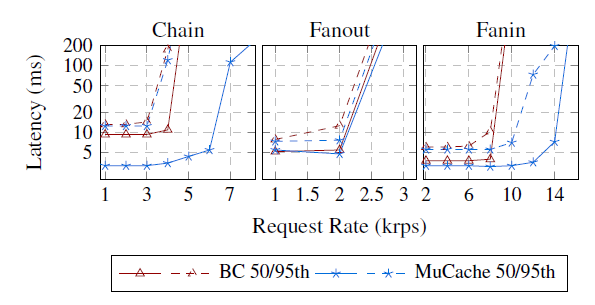

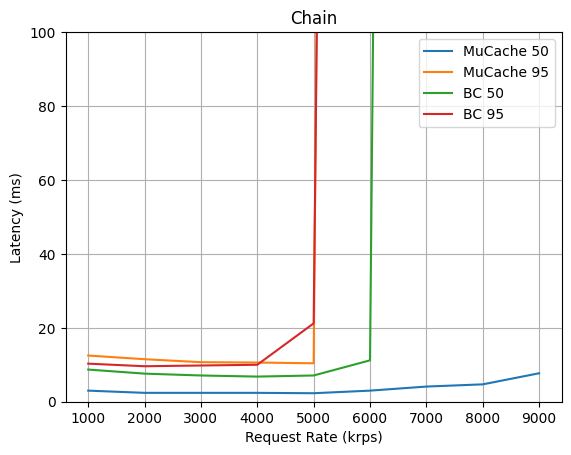

In [6]:
# Chain but with a single hop from service1 to backend and Zmq optimization
# Lower range to 100-1000
# Now we see MuCache match the performance of the baseline til 1000 RPS
# 1000-1500mi
x, bc_out = getStats( "chain-baseline-5000app-4zmq.json" )
_, mucache_out = getStats( "chain-5000app-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Chain", False, ylim = 100 )

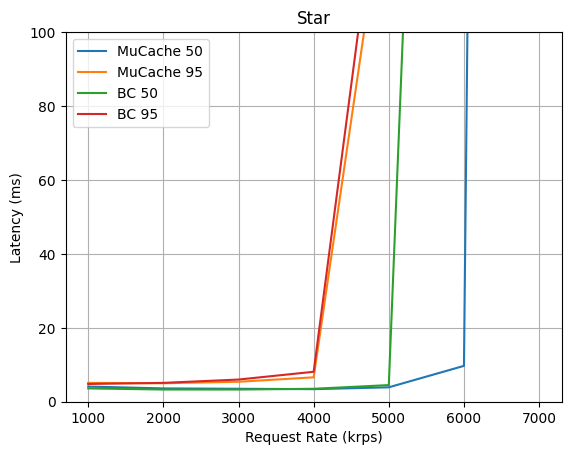

In [7]:
# Fanout/Star
x, bc_out = getStats( "star-baseline-5000app-4zmq.json" )
_, mucache_out = getStats( "star-5000app-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Star", False, ylim = 100 )

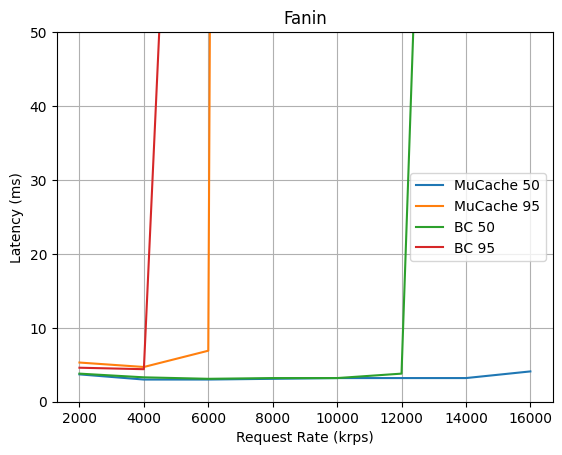

In [8]:
# Fanin
x, bc_out = getStats( "fanin-baseline-5000app-12proxyworkers-4zmq.json" )
_, mucache_out = getStats( "fanin-5000app-12proxyworkers-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]

plotStats( x, plots, "Request Rate (krps)", "Latency (ms)", "Fanin", False, ylim = 50 )

### Analysis
After massaging and adding additional resources to the experiments, it seems like MuCache does give beneficial advantages. It improves latency as well as the load limit of the microservice

## Hit Rate

In [9]:
# TODO new file
# Fanin
x, mucache_out = getStats( "fanin-510.json" )
_, bc_out = getStats( "fanin-baseline-510.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]]]SocialMedia
plotStats( x, plots, "Request Rate (krps)", "Latency (s)", "Fanin" )

SyntaxError: invalid syntax (2255685571.py, line 9)

## Real World Applications

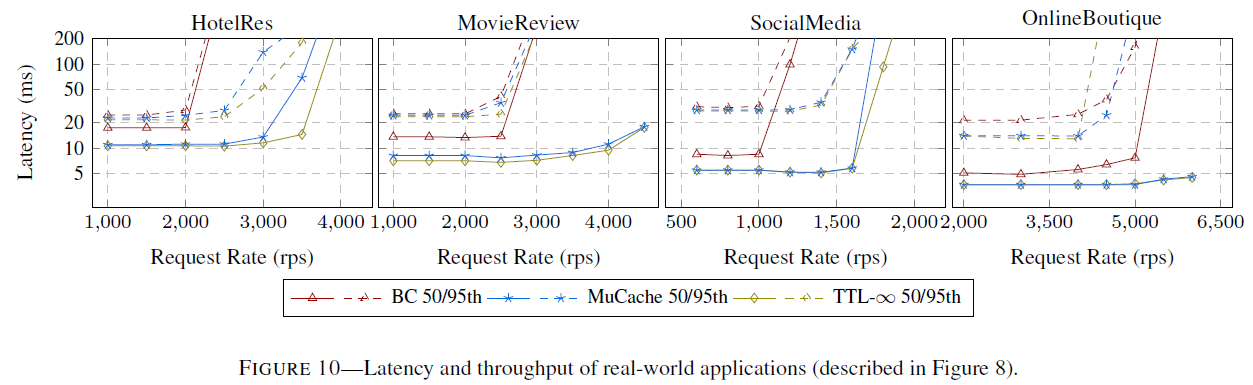

{'50': [11.299999999999999, 10.5, 10.1, 12.6, 22.2, 336.1, 14314.5, 6577.7], '95': [22.5, 16.1, 16.2, 20.1, 528.2, 3338.6, 22061.5, 8677.0], 'hit_rate': [{'frontend': '0.31', 'search': '0.84'}, {'frontend': '0.32'}, {'frontend': '0.32'}, {'search': '0.98'}, {'frontend': '0.31'}, {'frontend': '0.30', 'search': '0.97'}, {'frontend': '0.30'}, {'frontend': '0.31', 'search': '0.99'}], 'throughput': [500.0181, 1000.0088, 1499.9962, 1999.9827, 2498.457, 2999.9319, 2834.795, 3723.6152]}


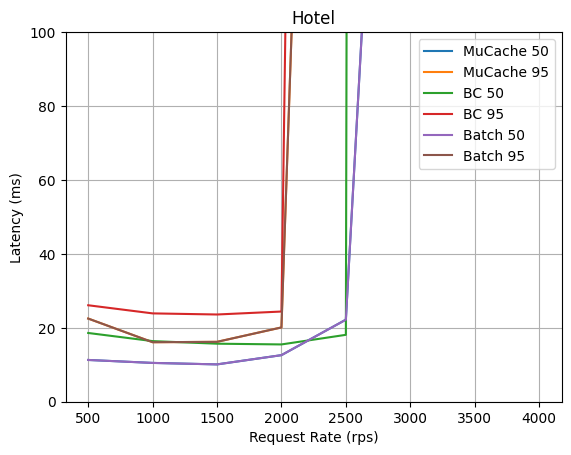

In [35]:
# HotelRes
x, bc_out = getStats( "hotel-baseline-1000hotelsize-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "hotel-1000hotelsize-5000app-12proxy-4zmq.json" )
_, ttl_out = getStats( "hotel-upper-1000hotelsize-5000app-12proxy-4zmq.json" )
# _, batch_out = getStats( "hotel-batch-1000hotelsize-5000app-12proxy-4zmq.json" )
print( mucache_out )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )

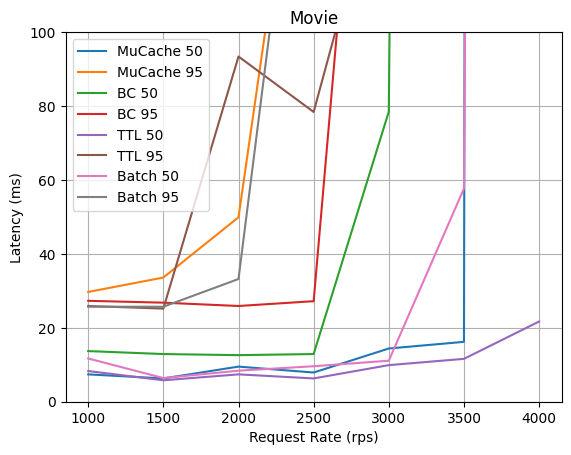

In [11]:
# MovieReview
x, bc_out = getStats( "movie-baseline-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "movie-5000app-12proxy-4zmq.json" )
_, ttl_out = getStats( "movie-upper-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "movie-batch-5000app-12proxyworkers-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Movie", ylim = 100 )

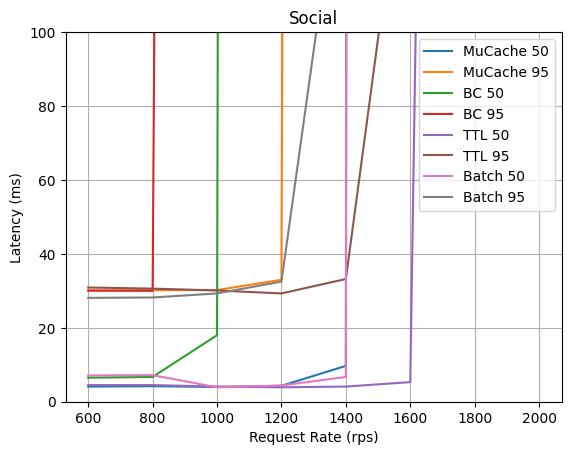

In [12]:
# SocialMedia
x, bc_out = getStats( "social-baseline-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "social-5000app-12proxy-4zmq.json" )
_, ttl_out = getStats( "social-upper-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "social-batch-5000app-12proxy-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Social", ylim = 100 )

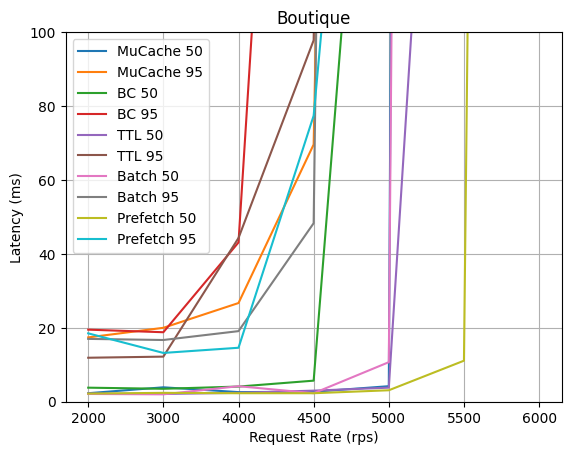

In [13]:
# OnlineBoutique (REDO)
x, bc_out = getStats( "boutique-baseline-halfSize-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "boutique-halfSize-5000app-12proxy-4zmq.json" )
_, ttl_out = getStats( "boutique-upper-halfSize-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "boutique-batch-halfSize-5000app-12proxy-4zmq.json" )
_, prefetch_out = getStats( "boutique-prefetch-halfSize-5000app-12proxy-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]],
         ["Prefetch 50", prefetch_out["50"]],
         ["Prefetch 95", prefetch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim = 100)

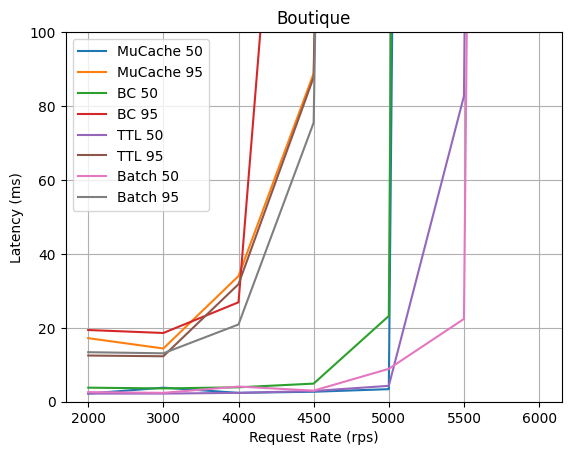

In [14]:
# OnlineBoutique (REDO)
x, bc_out = getStats( "boutique-baseline-halfSize-5000app-12proxy-4zmq-2.json" )
_, mucache_out = getStats( "boutique-halfSize-5000app-12proxy-4zmq-2.json" )
_, ttl_out = getStats( "boutique-upper-halfSize-5000app-12proxy-4zmq-2.json" )
_, batch_out = getStats( "boutique-batch-halfSize-5000app-12proxy-4zmq-2.json" )
#_, prefetch_out = getStats( "boutique-prefetch-halfSize-5000app-12proxy-4zmq-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         ["TTL 50", ttl_out["50"]],
         ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]],]
         # ["Prefetch 50", prefetch_out["50"]],
         # ["Prefetch 95", prefetch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim = 100)

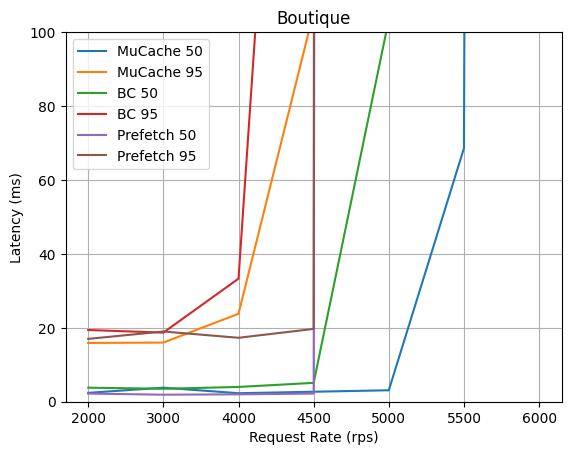

In [21]:
# OnlineBoutique (REDO)
x, bc_out = getStats( "boutique-baseline-nearbyUsers-halfProductSize-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "boutique-nearbyUsers-halfProductSize-5000app-12proxy-4zmq.json" )
# _, ttl_out = getStats( "boutique-upper-halfSize-5000app-12proxy-4zmq-2.json" )
# _, batch_out = getStats( "boutique-batch-halfSize-5000app-12proxy-4zmq-2.json" )
#_, prefetch_out = getStats( "boutique-prefetch-test-prefetch.json" )
#_, prefetch_out = getStats( "boutique-prefetch-test-nearby-1neighbor-10ms.json" )
#_, prefetch_out = getStats( "boutique-prefetch-test-nearby-2neighbor-10msTimeout.json" )
_, prefetch_out = getStats( "boutique-prefetch-test-nearby-2neighbor-originalContextWith10msTimeOut.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         # ["Batch 50", batch_out["50"]],
         # ["Batch 95", batch_out["95"]],]
         ["Prefetch 50", prefetch_out["50"]],
         ["Prefetch 95", prefetch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim=100 )

### Analysis
By adding resources and massaging the experiments, we found that MuCache has similar results to the microbenchmarks, where latency is lower than the baseline and the load limit of the microservices improves.

## Different TTL Baselines

DIDNT DO, DO IT